# Figures

In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))

from functions import *

#### Plot settings

In [2]:
# Plot settings
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'text.usetex': True}) # LaTeX capabilities
matplotlib.rcParams.update({'text.latex.preamble': r""})#, "font.serif": "Times"}) # pure LaTeX
# matplotlib.rcParams.update({'text.latex.preamble': r"", "font.serif": "Times"})  # Times new roman
matplotlib.rcParams.update({'font.family':'serif'})
matplotlib.rcParams.update({'font.size': 10})
matplotlib.rcParams.update({'axes.labelsize': 10, 'xtick.labelsize': 10, 'ytick.labelsize': 10})
get_ipython().run_line_magic('matplotlib', 'inline')
# get_ipython().run_line_magic('config', "InlineBackend.figure_format = 'svg' # render figures in SVG")

## reset
# matplotlib.rcdefaults()

matplotlib.rc('axes', linewidth=1.125)

matplotlib.rc('xtick.major', size=3, width=0.50)
matplotlib.rc('xtick.minor', size=3, width=0.50)
matplotlib.rc('ytick.major', size=3, width=0.50)
matplotlib.rc('ytick.minor', size=3, width=0.50)
matplotlib.rc('axes', linewidth=1.125)

import matplotlib as mpl
mpl.rcParams['xtick.direction'] = 'in'
mpl.rcParams['ytick.direction'] = 'in'
mpl.rcParams['xtick.top'] = True
mpl.rcParams['ytick.right'] = True

# to use \bm{}
plt.rcParams.update(
    {"text.usetex": True,
     "text.latex.preamble": r"\usepackage{bm}",
     "font.family": "serif", # enforce default LaTeX font.
     "font.serif": ["Computer Modern"],})

from matplotlib.colors import LogNorm

# Fig. 2

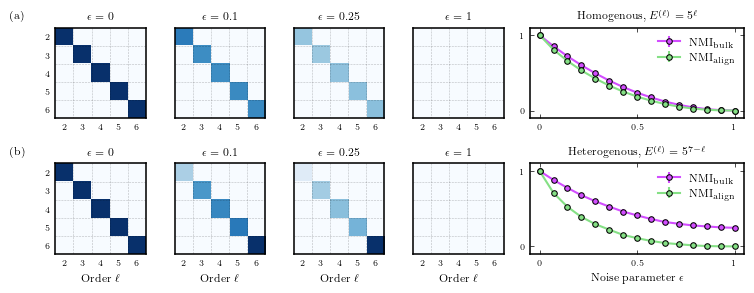

In [3]:
folder="../results/output/"

fig = plt.figure(figsize=(12,10)) # width x height in inches (ok for A4: 8.27 x 11.69)
fig.subplots_adjust(hspace=0.50)
fig.subplots_adjust(wspace=0.25)

ax1 = plt.subplot2grid((6,8), (0, 0))
ax2 = plt.subplot2grid((6,8), (0, 1))
ax3 = plt.subplot2grid((6,8), (0, 2))
ax4 = plt.subplot2grid((6,8), (0, 3))
ax5 = plt.subplot2grid((6,8), (0, 4), colspan=2)

ax6 = plt.subplot2grid((6,8), (1, 0))
ax7 = plt.subplot2grid((6,8), (1, 1))
ax8 = plt.subplot2grid((6,8), (1, 2))
ax9 = plt.subplot2grid((6,8), (1, 3))
ax10 = plt.subplot2grid((6,8), (1, 4), colspan=2)

axes = [ax1, ax2, ax3, ax4, ax5, ax6, ax7, ax8, ax9, ax10]

heatmaps=[ax1,ax2,ax3,ax4,  ax6,ax7,ax8,ax9]
for heatmap in heatmaps:
    heatmap.set_xticks([0,1,2,3,4], labels=[2,3,4,5,6], fontsize=6)
    heatmap.set_yticks([], labels=[], fontsize=6)
    heatmap.tick_params(axis='both', length=0.0) # effectively removing ticks
for heatmap in heatmaps[::4]: # taking only the first of each row
    heatmap.set_xticks([0,1,2,3,4], labels=[2,3,4,5,6], fontsize=6)
heatmaps[0].set_yticks([0,1,2,3,4], labels=[2,3,4,5,6], fontsize=6), heatmaps[4].set_yticks([0,1,2,3,4], labels=[2,3,4,5,6], fontsize=6)

curves=[ax5,ax10]
for curve in curves:
    curve.set_xticks([0, 0.5, 1], labels=[0,0.5,1], fontsize=6), curve.set_yticks([0,1], labels=[0,1], fontsize=6)
    curve.set_ylim(-0.10,1.1)
ax10.set_xlabel('Noise parameter $\epsilon$', fontsize=8, labelpad=5)
ax10.set_xticks([0, 0.5, 1], labels=[0,0.5,1], fontsize=6) 
for ax in [ax6,ax7,ax8,ax9]:
    ax.set_xlabel('Order $\ell$', fontsize=8, labelpad=5)
ax5.set_title(r'Homogenous, $E^{(\ell)} = 5^{\ell}$', fontsize=8)
ax10.set_title(r'Heterogenous, $E^{(\ell)} = 5^{7-\ell}$', fontsize=8)

"""
    load
"""
row1=[ax1,ax2,ax3,ax4]
row2=[ax6,ax7,ax8,ax9]
rows=[row1,row2]
N,d,E=100,6,10
nsim=10

"""     (a)     """
k=0
density="dense"
system=f"Hrandom-N-{N}-lmax-{d}-{density}"
NMIbulk=np.load(folder + f"results_{system}_NMIbulk_nsim-{nsim}.npy")
NMIalign=np.load(folder + f"results_{system}_NMIalign_nsim-{nsim}.npy",allow_pickle=True)
Ms=np.load(folder + f"results_{system}_heatmaps_nsim-{nsim}.npy")
ps=[0,0.1,0.25,1]
## heatmaps
for count,p in enumerate(ps):
    if count==len(ps)-1:
        M=np.zeros((d-1, d-1))
        rows[k][count].imshow(M, cmap='Blues',vmin=0, vmax=1)
        rows[k][count].set_title(f'$\epsilon=$ {1}', fontsize=8);
    else:
        rows[k][count].imshow(np.mean(Ms,axis=0)[count], cmap='Blues',vmin=0, vmax=1)
        rows[k][count].set_title(f'$\epsilon=$ {p}', fontsize=8);
    # Draw thin lines between entries
    num_rows, num_cols = np.mean(Ms,axis=0)[count].shape
    for i in range(num_rows): # horizontal
        rows[k][count].hlines(i+0.5, xmin=-0.5, xmax=num_cols-0.5, color='k',lw=0.40,alpha=0.25,ls="--",zorder=0)
    for i in range(num_cols): # vertical
        rows[k][count].vlines(i+0.5, ymin=-0.5, ymax=num_rows-0.5, color='k',lw=0.40,alpha=0.25,ls="--",zorder=0)
## curves
colors=['#85e085', '#d24dff'] # green and purple
epsilons=np.linspace(0, 1, NMIalign.shape[1])
ax5.errorbar(epsilons, np.mean(NMIbulk,axis=0), 3*np.std(NMIbulk,axis=0),
                            label=r"NMI$_{\rm bulk}$",
                            lw=1.50, marker='o', markersize=4.0, mec='k', mew=0.75, color=colors[1])
ax5.errorbar(epsilons, np.mean(NMIalign,axis=0), 3*np.std(NMIalign,axis=0),
                            label=r"NMI$_{\rm align}$",
                            lw=1.50, marker='o', markersize=4.0, mec='k', mew=0.75, color=colors[0])
ax5.legend(frameon=False, fontsize=8);

"""     (b)     """
k=1      
density="sparse"
system=f"Hrandom-N-{N}-lmax-{d}-{density}"
NMIbulk=np.load(folder + f"results_{system}_NMIbulk_nsim-{nsim}.npy")
NMIalign=np.load(folder + f"results_{system}_NMIalign_nsim-{nsim}.npy", allow_pickle=True) # allow_pickle because of the mpmath computation -- it makes the np.array 'unpure'
Ms=np.load(folder + f"results_{system}_heatmaps_nsim-{nsim}.npy")
ps=[0,0.1,0.25,1]
## heatmaps
for count,p in enumerate(ps):
    if count==len(ps)-1:
        M=np.zeros((d-1, d-1))
        rows[k][count].imshow(M, cmap='Blues',vmin=0, vmax=1)
        rows[k][count].set_title(f'$\epsilon=$ {1}', fontsize=8);
    else:
        rows[k][count].imshow(np.mean(Ms,axis=0)[count], cmap='Blues',vmin=0, vmax=1)
        rows[k][count].set_title(f'$\epsilon=$ {p}', fontsize=8);
    # Draw thin lines between entries
    num_rows, num_cols = np.mean(Ms,axis=0)[count].shape
    for i in range(num_rows): # horizontal
        rows[k][count].hlines(i+0.5, xmin=-0.5, xmax=num_cols-0.5, color='k',lw=0.40,alpha=0.25,ls="--",zorder=0)
    for i in range(num_cols): # vertical
        rows[k][count].vlines(i+0.5, ymin=-0.5, ymax=num_rows-0.5, color='k',lw=0.40,alpha=0.25,ls="--",zorder=0)
## curves
colors=['#85e085', '#d24dff'] # green and purple
epsilons=np.linspace(0, 1, NMIalign.shape[1])
ax10.errorbar(epsilons, np.mean(NMIbulk,axis=0), 3*np.std(NMIbulk,axis=0),
                            label=r"NMI$_{\rm bulk}$",
                            lw=1.50, marker='o', markersize=4.0, mec='k', mew=0.75, color=colors[1])
ax10.errorbar(epsilons, np.mean(NMIalign,axis=0), 3*np.std(NMIalign,axis=0),
                            label=r"NMI$_{\rm align}$",
                            lw=1.50, marker='o', markersize=4.0, mec='k', mew=0.75, color=colors[0]);
ax10.legend(frameon=False, fontsize=8);
panels=["(a)","(b)"]
for axs,panel in zip(*([ax1,ax6], panels)):
    axs.text(x=-3.0,y=-1.00,s=panel, fontsize=8);
# plt.savefig("fig2_v05.pdf", bbox_inches="tight", transparent=True);

# Fig. 3

/tmp/ipykernel_603061/3593859047.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  rows[k][count].set_xticklabels([r"NMI$_{\rm cross}$", r"NMI$_{\rm align}$"], fontsize=12, rotation=30)
/tmp/ipykernel_603061/3593859047.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  rows[k][count].set_xticklabels([r"NMI$_{\rm cross}$", r"NMI$_{\rm align}$"], fontsize=12, rotation=30)
/tmp/ipykernel_603061/3593859047.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  rows[k][count].set_xticklabels([r"NMI$_{\rm cross}$", r"NMI$_{\rm align}$"], fontsize=12, rotation=30)
/tmp/ipykernel_603061/3593859047.py:87: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  rows[k][cou

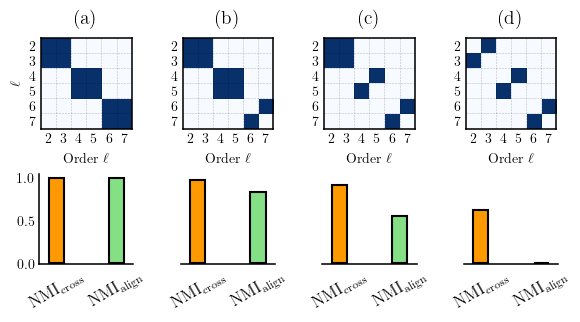

In [4]:
folder="../results/output/"

fig = plt.figure(figsize=(14,10)) # width x height in inches (ok for A4: 8.27 x 11.69)
fig.subplots_adjust(hspace=0.500)
fig.subplots_adjust(wspace=0.500)

ax1 = plt.subplot2grid((6,8), (0, 0))
ax2 = plt.subplot2grid((6,8), (0, 1))
ax3 = plt.subplot2grid((6,8), (0, 2))
ax4 = plt.subplot2grid((6,8), (0, 3))

ax6 = plt.subplot2grid((6,8), (1, 0))
ax7 = plt.subplot2grid((6,8), (1, 1))
ax8 = plt.subplot2grid((6,8), (1, 2))
ax9 = plt.subplot2grid((6,8), (1, 3))


axes = [ax1, ax2, ax3, ax4, #ax5, 
        ax6, ax7, ax8, ax9,] #ax10]

heatmaps=[ax1,ax2,ax3,ax4]
for heatmap in heatmaps:
    heatmap.set_xticks([0,1,2,3,4,5], labels=[2,3,4,5,6,7], fontsize=10)
    heatmap.set_yticks([0,1,2,3,4,5], labels=[2,3,4,5,6,7], fontsize=10)
    heatmap.tick_params(axis='both', length=0.0) # effectively removing ticks
for heatmap in heatmaps[::4]: # taking only the first of each row
    heatmap.set_yticks([0,1,2,3,4,5], labels=[2,3,4,5,6,7], fontsize=10)
    
barplots=[ax6,ax7,ax8,ax9]
for barplot in barplots:
    barplot.spines['top'].set_visible(False)
    barplot.spines['right'].set_visible(False)
    barplot.spines['left'].set_visible(False)
    barplot.get_xaxis().tick_bottom()
    barplot.get_yaxis().tick_left()
    barplot.set_ylim(-0.0125, 1.00+0.05)
    barplot.tick_params(axis='both', length=0.0)
    if barplot in [ax7,ax8,ax9]: barplot.set_yticks([], labels=[], fontsize=10)
    else: continue
ax6.spines['left'].set_visible(True)

for ax in [ax1,ax2,ax3,ax4]:
    ax.set_xlabel('Order $\ell$', fontsize=10, labelpad=5)
ax1.set_ylabel('$\ell$', fontsize=10, labelpad=5)


"""
    now we load and plot the heatmap data
"""

row1=[ax1,ax2,ax3,ax4]
row2=[ax6,ax7,ax8,ax9]
rows=[row1,row2]

with open(folder + "results_blocknested_heatmap-NMIalign-NMI-cross.pkl", 'rb') as f: 
    results = pickle.load(f)
Ms=[results[i][0] for i in range(len(results))]
NMIaligns=[results[i][1] for i in range(len(results))]
NMIcrosss=[results[i][2] for i in range(len(results))]


"""1st row"""
k=0
## heatmaps
panels=["(a)", "(b)", "(c)", "(d)"]
for count, _ in enumerate(results):
    rows[k][count].imshow(Ms[count], cmap='Blues',vmin=0, vmax=1)
    rows[k][count].set_title(f'{panels[count]}', fontsize=14, pad=10);
           
    # Draw thin lines between entries
    num_rows, num_cols = Ms[count].shape
    for i in range(num_rows): # horizontal
        rows[k][count].hlines(i+0.5, xmin=-0.5, xmax=num_cols-0.5, color='k',lw=0.40,alpha=0.25,ls="--",zorder=0)
    for i in range(num_cols): # vertical
        rows[k][count].vlines(i+0.5, ymin=-0.5, ymax=num_rows-0.5, color='k',lw=0.40,alpha=0.25,ls="--",zorder=0)

"""2nd row"""
k=1
## barplots
for count, _ in enumerate(results):
    rows[k][count].margins(0.125, 0)
    rows[k][count].bar([r"NMI$_{\rm cross}$", r"NMI$_{\rm align}$"], [NMIcrosss[count], NMIaligns[count]],
                width=0.250,
                color=['#ff9900', '#85e085'], # orange and green
                edgecolor='black',
                linewidth=1.5)
    rows[k][count].set_xticklabels([r"NMI$_{\rm cross}$", r"NMI$_{\rm align}$"], fontsize=12, rotation=30)
    rows[k][count].tick_params(axis='x', rotation=30);
    
# plt.savefig("fig3_v06.pdf", bbox_inches="tight", transparent=True);

# Fig. multiscale

/tmp/ipykernel_603061/2518458355.py:25: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('Oranges')


Text(0.5, 1.0, '(b)')

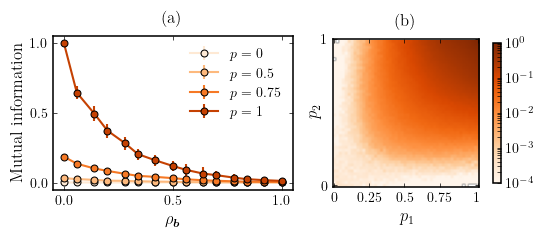

In [5]:
folder="../results/output/"

fig = plt.figure(figsize=(5.5, 2)) # width x height in inches (ok for A4: 8.27 × 11.69)
fig.subplots_adjust(wspace=0.75)

# Use 5 columns to give ax1 more space
ax1 = plt.subplot2grid((1, 5), (0, 0), colspan=3)  # Takes columns 0, 1, 2
ax2 = plt.subplot2grid((1, 5), (0, 3), colspan=2)  # Takes columns 3, 4
axes = [ax1, ax2]

"""NMIcross,b curves"""
within_noises = [0,0.5,0.75,1]
between_noises = np.linspace(0,N/2,15).astype('int')
NMIcross_ps=np.load(folder + "results_NMIcross-bs-ps.npy")

i=0
axes[i].set_xlabel(r"$\rho_{\bm{b}}$", fontsize=12)
axes[i].set_ylabel("Mutual information", fontsize=12)
axes[i].set_ylim(-0.05,1.05);

from matplotlib import cm
### Instead of using full range [0, 1], use a slightly darker slice [0.3, 0.9]
n_colors = len(within_noises)
color_vals = np.linspace(0.10, 0.80, n_colors) # avoid ultra-light and ultra-dark ends
cmap = cm.get_cmap('Oranges')
colors = [cmap(val) for val in color_vals]

for count, pwithin in enumerate(within_noises):
    axes[i].errorbar(np.array(between_noises)/max(between_noises), 
                 np.mean(NMIcross_ps[count], axis=0),
                 3*np.std(NMIcross_ps[count], axis=0),
         lw=1.50, marker='o', markersize=5.0, mec='k', mew=0.75, color=colors[count],
         label=r"$p=$" + f" {pwithin}")
    
axes[i].legend(frameon=False,fontsize=10)
axes[i].set_xticks(ticks=[0,0.5,1.0], labels=[0.0,0.5,1.0])
axes[i].set_yticks(ticks=[0,0.5,1.0], labels=[0.0,0.5,1.0]);

"""NMIcross,b heatmap"""
i=1
M = np.load(folder + "results_p1p2_heatmap_50x50_nsim-10.npy")
num_shuffles,max_shuffle=0,500
im = axes[i].imshow(M, cmap="Oranges",norm=LogNorm(vmin=1e-4,vmax=1))
cax = fig.add_axes([0.925, 0.144, 0.015, 0.70]) # [x, y, width, height]
cbar=fig.colorbar(im, cax=cax, orientation='vertical')
axes[i].invert_yaxis()
axes[i].set_xlabel("$p_1$",fontsize=12)
axes[i].set_ylabel("$p_2$",fontsize=12, labelpad=0)

labels_int = [0, int((len(M)-1)/4), int((len(M)-1)/2), int(3*(len(M)-1)/4), len(M)-1]
labels_str = [0, 0.25, 0.5, 0.75, 1]
axes[i].set_xticks(ticks=labels_int, labels=labels_str)
axes[i].set_yticks(ticks=[0,50], labels=[0,1]);

ax1.set_title("(a)",color='k', fontsize=12, pad=10) # (a)
ax2.set_title("(b)",color='k', fontsize=12, pad=10) # (b)

# plt.savefig("fig4_v02.pdf", bbox_inches="tight", transparent=True);